# Tile Download Verification

Across the 3 foundation-model tile sets (full dataset):
- **CROMA** — 120×120 px, products: `s2_l2a`, `s1_grd`
- **TerraFM** — 224×224 px, products: `s2_l2a`, `s1_rtc`
- **Clay** — 256×256 px, products: `s2_l2a`, `s1_rtc`

Checks:
1. How many tiles were downloaded per model × product × window
2. Which sample FIDs are missing per set, version info from v1/v2/v3 CSVs
3. Tile integrity: dimensions, band count, file size
4. Missing image IDs per FID (expected from CSVs vs on disk)
5. Empty tiles, S1 statistics, disk usage, grid alignment
6. Delete the duplicates and the specific noisy image
7. Longest time series per disturbance type

## 0. Setup — imports, configuration, data & helpers

Run these cells once. They are independent of every analysis section below.

In [5]:
# ── All imports ──
import os
import csv
import json
import glob
import math
import random
import re
import shutil
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon

from shapely.geometry import box

In [3]:
# ── Configuration: paths, tile sets and constants ──

# Paths
SCRIPT_DIR = os.path.dirname(os.path.abspath("__file__"))
SHP_DIR = os.path.join(SCRIPT_DIR, "data_shp")
if os.path.exists(os.path.expanduser("~/thesis_scripts/data_shp")):
    SHP_DIR = os.path.expanduser("~/thesis_scripts/data_shp")
CSV_DIR = os.path.join(SCRIPT_DIR, "data_csv")
SHP_PATH = os.path.join(SHP_DIR, "label_polygons.shp")

# Base directory for tile sets
if os.path.exists(os.path.expanduser("~/thesis_tiles_120px")):
    BASE = os.path.expanduser("~")
else:
    BASE = "/Users/angelicamariamorenorojas/Desktop/Master/thesis"

# 3 tile sets, one per foundation model
TILE_SETS = {
    "CROMA":   {"dir": os.path.join(BASE, "thesis_tiles_120px"), "size": 120, "products": ["s2_l2a", "s1_grd"]},
    "TerraFM": {"dir": os.path.join(BASE, "thesis_tiles_224px"), "size": 224, "products": ["s2_l2a", "s1_rtc"]},
    "Clay":    {"dir": os.path.join(BASE, "thesis_tiles_256px"), "size": 256, "products": ["s2_l2a", "s1_rtc"]},
}

WINDOWS = ["evt", "bef", "aft"]
EXPECTED_BANDS = {"s2_l2a": 12, "s1_grd": 2, "s1_rtc": 2}
ALL_PRODUCTS = sorted({p for s in TILE_SETS.values() for p in s["products"]})

# CSV parsing
CSV_FILES = ["v1_images_s2_s1.csv", "v2_images_s2_s1.csv", "v3_images_s2_s1.csv"]
IMAGE_ID_COLUMNS = {
    ("s2", "evt"): "evtIdsS2", ("s2", "bef"): "befIdsS2", ("s2", "aft"): "aftIdsS2",
    ("s1", "evt"): "evtIdsS1", ("s1", "bef"): "befIdsS1", ("s1", "aft"): "aftIdsS1",
}
COLS_TO_SHOW = ["fid", "VIEW_DATE", "CLASSNAME", "MUNICIPALI", "UF",
                "area_km2", "polygon_px",
                "evtFndS2", "befFndS2", "aftFndS2",
                "evtFndS1", "befFndS1", "aftFndS1"]

# For each model, which product answers which sensor
SENSOR_TO_PRODUCT_FOR_SET = {
    "CROMA":   {"s2": "s2_l2a", "s1": "s1_grd"},
    "TerraFM": {"s2": "s2_l2a", "s1": "s1_rtc"},  # s1 ids from CSV are GRD, reused for RTC
    "Clay":    {"s2": "s2_l2a", "s1": "s1_rtc"},
}

# Empty-tile / duplicate checks
PRODUCT = "s2_l2a"      # only S2 uses the MGRS grid -> only place S2 duplicates occur
S1_PRODUCT = "s1_grd"
THRESHOLD = 0.01        # fraction of all-band-nodata pixels to flag a tile as empty
MIN_DATES = 1          # minimum acquisitions a FID should keep after dropping empties

# Grid alignment artifact
TARGET_FID = "387"

In [4]:
# ── Show the tile-set table ──
print(f"CSV directory: {CSV_DIR}")
print()
print(f"{'Model':<10} {'Tile dir':<45} {'Size':>6} {'Products'}")
print("-" * 90)
for model, cfg in TILE_SETS.items():
    exists = "✓" if os.path.exists(cfg["dir"]) else "✗ MISSING"
    print(f"{model:<10} {cfg['dir']:<45} {cfg['size']:>4}² {'+'.join(cfg['products'])}  {exists}")

CSV directory: /share/castor/home/e2406749/tropical_forest_disturbance/data_csv

Model      Tile dir                                        Size Products
------------------------------------------------------------------------------------------
CROMA      /share/home/e2406749/thesis_tiles_120px        120² s2_l2a+s1_grd  ✓
TerraFM    /share/home/e2406749/thesis_tiles_224px        224² s2_l2a+s1_rtc  ✗ MISSING
Clay       /share/home/e2406749/thesis_tiles_256px        256² s2_l2a+s1_rtc  ✗ MISSING


In [5]:
# Load label polygons (WGS 84), reproject to UTM 20S (SIRGAS 2000)
_gdf = gpd.read_file(SHP_PATH)
_gdf["fid"] = _gdf["fid"].astype(int).astype(str)
_gdf_utm = _gdf.to_crs("EPSG:31980")
_gdf_utm["area_px"] = (_gdf_utm.geometry.area / 10).round().astype(int)

# fid -> polygon pixel count
poly_pixels = dict(zip(_gdf["fid"], _gdf_utm["area_px"]))
# fid -> disturbance type
fid_to_type = dict(zip(_gdf["fid"], _gdf["CLASSNAME"]))

print(f"Loaded {len(_gdf)} label polygons")

Loaded 389 label polygons


In [7]:
# ── Helper functions used across the analysis sections ──

def longest_series_per_type(expected_all, fid_to_type, top_n=2,
                            min_per_window=2, sensors=("s2",)):
    """FIDs with the most images per disturbance type, from CSV data (not disk).

    Only FIDs whose every window has >= min_per_window images (for `sensors`)
    are considered. Returns {disturbance_type: [(fid, image_count), ...]}.
    """
    windows = ("bef", "evt", "aft")

    def passes_window_min(sw_dict):
        """True if EACH window has >= min_per_window images (for the given sensors)."""
        for win in windows:
            n = sum(len(sw_dict.get((s, win), {})) for s in sensors)
            if n < min_per_window:
                return False
        return True

    # fid -> total #images, only for fids that pass the per-window minimum
    fid_to_count = {}
    for fid, sw_dict in expected_all.items():
        if not passes_window_min(sw_dict):
            continue
        fid_to_count[fid] = sum(len(ids) for ids in sw_dict.values())

    # group fids by disturbance type
    by_type = defaultdict(list)
    for fid, count in fid_to_count.items():
        ctype = fid_to_type.get(fid)
        if ctype is None:
            continue
        by_type[ctype].append((fid, count))

    # sort and keep top_n per type
    result = {}
    for ctype, fids in by_type.items():
        fids_sorted = sorted(fids, key=lambda x: (-x[1], int(x[0])))
        result[ctype] = fids_sorted[:top_n]
    return result


def plot_s1(tif, vmin=-25, vmax=0, shp_path=SHP_PATH):
    """Show an S1 GRD tile (VV, VH, false color) with the FID polygon overlaid."""
    with rasterio.open(tif) as src:
        vv, vh = src.read(1).astype("float32"), src.read(2).astype("float32")
        crs, transform = src.crs, src.transform

    # FID from the path: .../s1_grd/fid_<N>/...
    fid = next(p[len("fid_"):] for p in Path(tif).parts if p.startswith("fid_"))
    gdf = gpd.read_file(shp_path)
    gdf["fid"] = gdf["fid"].astype(int).astype(str)
    poly = gdf[gdf["fid"] == fid].to_crs(crs).geometry.iloc[0]
    geoms = [poly] if poly.geom_type == "Polygon" else list(poly.geoms)

    def norm(x):  # dB -> [0,1]
        return np.clip((x - vmin) / (vmax - vmin), 0, 1)

    def draw_poly(ax):  # world coords -> pixel coords via inverse transform
        for g in geoms:
            pix = [~transform * (x, y) for x, y in zip(*g.exterior.xy)]
            ax.add_patch(MplPolygon(pix, fill=False, edgecolor="red", lw=2))

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(norm(vv), cmap="gray"); ax[0].set_title("VV (dB)")
    ax[1].imshow(norm(vh), cmap="gray"); ax[1].set_title("VH (dB)")
    for a in ax:
        draw_poly(a); a.axis("off")
    plt.suptitle(tif.split("/s1_grd/")[-1])
    plt.tight_layout(); plt.show()


def dir_size_gb(path):
    """Total size (GB) of every file under `path`."""
    total = 0
    for dirpath, _, filenames in os.walk(path):
        for f in filenames:
            total += os.path.getsize(os.path.join(dirpath, f))
    return total / 1e9


def create_tile_grid(polygon_3857, tile_size_m):
    """Replicate create_tile_grid from tile_pipeline.py (grid anchored to EPSG:3857)."""
    minx, miny, maxx, maxy = polygon_3857.bounds
    grid_minx = math.floor(minx / tile_size_m) * tile_size_m
    grid_miny = math.floor(miny / tile_size_m) * tile_size_m
    grid_maxx = math.ceil(maxx / tile_size_m) * tile_size_m
    grid_maxy = math.ceil(maxy / tile_size_m) * tile_size_m
    tiles = []
    x = grid_minx
    while x < grid_maxx:
        y = grid_miny
        while y < grid_maxy:
            t = box(x, y, x + tile_size_m, y + tile_size_m)
            if t.intersects(polygon_3857):
                tiles.append(t)
            y += tile_size_m
        x += tile_size_m
    return tiles


def duplicates_check(delete_=False):
    """S2 duplicates: two folders for the same acquisition day under one window.

    Keep the first folder, report (and optionally delete) the rest.
    """
    to_delete = 0
    dup_fids = set()
    for model, cfg in TILE_SETS.items():
        product_dir = Path(cfg["dir"], PRODUCT)
        if not product_dir.exists():
            continue
        # each fid_*/<window>/ holds one folder per acquisition
        for window_dir in sorted(product_dir.glob("fid_*/*")):
            if not window_dir.is_dir():
                continue
            by_day = defaultdict(list)
            for leaf in sorted(window_dir.iterdir()):
                if leaf.is_dir():
                    day = leaf.name[:8]          # YYYYMMDD
                    by_day[day].append(leaf)
            for day, folders in by_day.items():
                for f in folders[1:]:            # keep the first, drop the rest
                    print(f"[{model}] {f.relative_to(cfg['dir'])}")
                    to_delete += 1
                    dup_fids.add(window_dir.parent.name.replace("fid_", ""))
                    if delete_:
                        shutil.rmtree(f)

    print(f"\nFolders to delete: {to_delete}")
    print(f"Duplicate FIDs: {sorted(dup_fids)}")
    print(f"Total unique FIDs with duplicates: {len(dup_fids)}")


def _s1_acq_date(folder_name):
    # S1 folder: S1A_IW_GRDH_1SDV_<start>T..._<stop>T..._<orbit>_<datatake>_<id>
    m = re.search(r"_(\d{8})T", folder_name)
    return m.group(1) if m else folder_name[:8]


def _s1_tile0_nodata(folder):
    # Fraction of all-band-nodata pixels in the first tile, to decide which frame to keep
    tifs = sorted(glob.glob(os.path.join(folder, "tile_*.tif")))
    if not tifs:
        return 1.0
    with rasterio.open(tifs[0]) as src:
        arr = src.read().astype("float32")
    return float((np.nan_to_num(arr) == 0).all(axis=0).mean())


def duplicates_check_s1(delete_=False):
    """S1 duplicates: along-track GRD frame overlap on the same acquisition day.

    All S1 here is descending, so two folders on the same day = the SAME pass
    split across two overlapping GRD frames (footprint near a frame edge), NOT
    ascending vs descending. Keep the frame with least nodata, report the rest.
    """
    to_delete = 0
    dup_fids = set()
    for model, cfg in TILE_SETS.items():
        if S1_PRODUCT not in cfg["products"]:
            continue
        product_dir = Path(cfg["dir"], S1_PRODUCT)
        if not product_dir.exists():
            continue
        # each fid_*/<window>/ holds one folder per acquisition
        for window_dir in sorted(product_dir.glob("fid_*/*")):
            if not window_dir.is_dir():
                continue
            by_day = defaultdict(list)
            for leaf in sorted(window_dir.iterdir()):
                if leaf.is_dir():
                    by_day[_s1_acq_date(leaf.name)].append(leaf)
            for day, folders in by_day.items():
                if len(folders) < 2:
                    continue  # single frame that day -> nothing to dedup
                fid = window_dir.parent.name.replace("fid_", "")
                dup_fids.add(fid)
                ranked = sorted(folders, key=_s1_tile0_nodata)  # least nodata first
                keep, drop = ranked[0], ranked[1:]
                print(f"[{model}] fid {fid} | {window_dir.name} | {day} | {len(folders)} frames")
                print(f"    keep {keep.name}  ({_s1_tile0_nodata(keep):.0%} nodata)")
                for f in drop:
                    print(f"    drop {f.name}  ({_s1_tile0_nodata(f):.0%} nodata)")
                    to_delete += 1
                    if delete_:
                        shutil.rmtree(f)

    print(f"\nFrames to delete: {to_delete}")
    print(f"FIDs with S1 overlap duplicates: {sorted(dup_fids, key=int)}")
    print(f"Total unique FIDs with S1 duplicates: {len(dup_fids)}")

## 1. Scan downloaded tiles

In [6]:
# Count .tif files per (model, product, window).
# Structure: downloaded[model][product][window] = [paths]
downloaded = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for model, cfg in TILE_SETS.items():
    for product in cfg["products"]:
        product_dir = os.path.join(cfg["dir"], product)
        if not os.path.exists(product_dir):
            continue
        for tif in glob.glob(os.path.join(product_dir, "fid_*", "*", "*", "*.tif")):
            parts = Path(tif).parts
            fid_idx = next(i for i, p in enumerate(parts) if p.startswith("fid_"))
            fid = parts[fid_idx].replace("fid_", "")
            window = parts[fid_idx + 1]
            downloaded[model][product][window].append(tif)

# Summary table: model x product rows, window columns
print(f"{'Model':<8} {'Product':<10} {'evt':>8} {'bef':>8} {'aft':>8} {'TOTAL':>8}")
print("-" * 56)
grand_total = 0
for model, cfg in TILE_SETS.items():
    for product in cfg["products"]:
        counts = {w: len(downloaded[model][product][w]) for w in WINDOWS}
        total = sum(counts.values())
        grand_total += total
        print(f"{model:<8} {product:<10} {counts['evt']:>8} {counts['bef']:>8} {counts['aft']:>8} {total:>8}")
print("-" * 56)
print(f"{'TOTAL':<19} {'':>8} {'':>8} {'':>8} {grand_total:>8}")

Model    Product         evt      bef      aft    TOTAL
--------------------------------------------------------
CROMA    s2_l2a         1546    11743     2054    15343
CROMA    s1_grd         1103    14302     1441    16846
TerraFM  s2_l2a            0        0        0        0
TerraFM  s1_rtc            0        0        0        0
Clay     s2_l2a            0        0        0        0
Clay     s1_rtc            0        0        0        0
--------------------------------------------------------
TOTAL                                             32189


## 2. Expected vs Downloaded (from CSVs)

if ANY filter version found an image useful, we download it. The expected table shows the total unique images across all versions, which is exactly what the pipeline should have downloaded.

In [7]:
# Parse v1/v2/v3 CSVs. For each (fid, sensor, window, image_id) track which
# filter versions listed that image. All FIDs in the CSVs.
# expected[fid][(sensor, window)] = {image_id: set(versions that include it)}
expected = defaultdict(lambda: defaultdict(lambda: defaultdict(set)))

for csv_name in CSV_FILES:
    version = csv_name.split("_")[0]  # v1, v2, v3
    csv_path = os.path.join(CSV_DIR, csv_name)
    if not os.path.exists(csv_path):
        print(f"WARNING: {csv_path} not found")
        continue
    with open(csv_path, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            fid = row["fid"].strip()
            if not fid:
                continue
            for (sensor, window), col in IMAGE_ID_COLUMNS.items():
                raw = row.get(col, "").strip()
                if not raw:
                    continue
                ids = [x.strip() for x in raw.split(",") if x.strip()]
                for img_id in ids:
                    expected[fid][(sensor, window)][img_id].add(version)

# Count unique (fid, window, image_id) per sensor across the sample
expected_counts = defaultdict(lambda: defaultdict(int))
version_only_counts = defaultdict(int)  # images appearing in only 1 version

for fid, sw_dict in expected.items():
    for (sensor, window), id_versions in sw_dict.items():
        expected_counts[sensor][window] += len(id_versions)
        for img_id, versions in id_versions.items():
            if len(versions) == 1:
                version_only_counts[list(versions)[0]] += 1

print(f"FIDs with data in CSVs: {len(expected)}")
print()
print(f"Expected unique images per sensor (all FIDs):")
print(f"{'Sensor':<8} {'evt':>8} {'bef':>8} {'aft':>8} {'TOTAL':>8}")
print("-" * 44)
for sensor in ["s2", "s1"]:
    row = {w: expected_counts[sensor][w] for w in WINDOWS}
    total = sum(row.values())
    print(f"{sensor:<8} {row['evt']:>8} {row['bef']:>8} {row['aft']:>8} {total:>8}")

print("\nImages appearing in ONLY one filter version (cloud filter differences):")
for v in ["v1", "v2", "v3"]:
    print(f"  Only in {v}: {version_only_counts[v]}")

FIDs with data in CSVs: 389

Expected unique images per sensor (all FIDs):
Sensor        evt      bef      aft    TOTAL
--------------------------------------------
s2            695     4846      945     6486
s1            425     5395      550     6370

Images appearing in ONLY one filter version (cloud filter differences):
  Only in v1: 839
  Only in v2: 4
  Only in v3: 0


In [8]:
per_version = defaultdict(set)
for fid, sw_dict in expected.items():
    for (sensor, window), id_versions in sw_dict.items():
        for img_id, versions in id_versions.items():
            for v in versions:
                per_version[v].add((fid, sensor, window, img_id))

print("Total images per version (sample only):")
for v in ["v1", "v2", "v3"]:
    print(f"  {v}: {len(per_version[v])} images")

print("\nOverlap matrix (intersection sizes):")
print(f"{'':>4} {'v1':>6} {'v2':>6} {'v3':>6}")
for a in ["v1", "v2", "v3"]:
    row = f"{a:>4}"
    for b in ["v1", "v2", "v3"]:
        row += f" {len(per_version[a] & per_version[b]):>6}"
    print(row)

print("\nExclusive (in exactly one version):")
only_v1 = len(per_version["v1"] - per_version["v2"] - per_version["v3"])
only_v2 = len(per_version["v2"] - per_version["v1"] - per_version["v3"])
only_v3 = len(per_version["v3"] - per_version["v1"] - per_version["v2"])
print(f"  Only v1 (not v2, not v3): {only_v1}")
print(f"  Only v2 (not v1, not v3): {only_v2}")
print(f"  Only v3 (not v1, not v2): {only_v3}")

print("\nNested check:")
print(f"  v2 subset of v1?  {per_version['v2'].issubset(per_version['v1'])}")
print(f"  v3 subset of v2?  {per_version['v3'].issubset(per_version['v2'])}")
print(f"  v3 subset of v1?  {per_version['v3'].issubset(per_version['v1'])}")

Total images per version (sample only):
  v1: 12822 images
  v2: 12017 images
  v3: 11558 images

Overlap matrix (intersection sizes):
         v1     v2     v3
  v1  12822  11983  11528
  v2  11983  12017  11558
  v3  11528  11558  11558

Exclusive (in exactly one version):
  Only v1 (not v2, not v3): 839
  Only v2 (not v1, not v3): 4
  Only v3 (not v1, not v2): 0

Nested check:
  v2 subset of v1?  False
  v3 subset of v2?  True
  v3 subset of v1?  False


In [9]:
# Per-version CSV table (polygon pixel count from the shapefile)
for csv_name in CSV_FILES:
    csv_path = os.path.join(CSV_DIR, csv_name)
    if not os.path.exists(csv_path):
        print(f"WARNING: {csv_path} not found")
        continue
    df = pd.read_csv(csv_path)
    df["fid"] = df["fid"].astype(str)
    df["polygon_px"] = df["fid"].map(poly_pixels)
    cols = [c for c in COLS_TO_SHOW if c in df.columns]
    print(f"\n========== {csv_name} ({len(df)} rows) ==========")
    display(df[cols].sort_values("fid", key=lambda s: s.astype(int)).reset_index(drop=True))


========== v1_images_s2_s1.csv (389 rows) ==========


,fid,VIEW_DATE,CLASSNAME,MUNICIPALI,UF,area_km2,polygon_px,evtFndS2,befFndS2,aftFndS2,evtFndS1,befFndS1,aftFndS1
0,1,1695970800000,Fire scar,Porto Velho,RO,0.180325,17944,3,16,0,1,19,2
1,2,1695970800000,Disorderly Selective logging,Cujubim,RO,18.739051,1864677,3,16,1,1,19,2
2,3,1695970800000,Disorderly Selective logging,Itapua do Oeste,RO,0.463429,46115,3,20,1,1,19,2
3,4,1695970800000,Clear-cut bare soil,Porto Velho,RO,0.068661,6832,1,19,1,1,19,2
4,5,1695970800000,Clear-cut bare soil,Porto Velho,RO,0.078494,7811,1,22,1,1,19,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,385,1698562800000,Disorderly Selective logging,Candeias do Jamari,RO,7.662009,762408,0,21,2,1,21,1
385,386,1692082800000,Clear-cut bare soil,Candeias do Jamari,RO,0.086778,8635,2,16,3,1,16,2
386,387,1692082800000,Degradation,Porto Velho,RO,0.187002,18608,1,16,3,1,16,2
387,388,1695970800000,Clear-cut bare soil,Candeias do Jamari,RO,0.103300,10279,4,39,3,1,19,2



========== v2_images_s2_s1.csv (389 rows) ==========


,fid,VIEW_DATE,CLASSNAME,MUNICIPALI,UF,area_km2,polygon_px,evtFndS2,befFndS2,aftFndS2,evtFndS1,befFndS1,aftFndS1
0,1,1695970800000,Fire scar,Porto Velho,RO,0.180325,17944,3,15,0,1,19,2
1,2,1695970800000,Disorderly Selective logging,Cujubim,RO,18.739051,1864677,3,15,1,1,19,2
2,3,1695970800000,Disorderly Selective logging,Itapua do Oeste,RO,0.463429,46115,3,17,0,1,19,2
3,4,1695970800000,Clear-cut bare soil,Porto Velho,RO,0.068661,6832,1,18,1,1,19,2
4,5,1695970800000,Clear-cut bare soil,Porto Velho,RO,0.078494,7811,1,19,1,1,19,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,385,1698562800000,Disorderly Selective logging,Candeias do Jamari,RO,7.662009,762408,0,19,1,1,21,1
385,386,1692082800000,Clear-cut bare soil,Candeias do Jamari,RO,0.086778,8635,2,15,2,1,16,2
386,387,1692082800000,Degradation,Porto Velho,RO,0.187002,18608,1,15,2,1,16,2
387,388,1695970800000,Clear-cut bare soil,Candeias do Jamari,RO,0.103300,10279,4,35,3,1,19,2



========== v3_images_s2_s1.csv (389 rows) ==========


,fid,VIEW_DATE,CLASSNAME,MUNICIPALI,UF,area_km2,polygon_px,evtFndS2,befFndS2,aftFndS2,evtFndS1,befFndS1,aftFndS1
0,1,1695970800000,Fire scar,Porto Velho,RO,0.180325,17944,3,14,0,1,19,2
1,2,1695970800000,Disorderly Selective logging,Cujubim,RO,18.739051,1864677,3,12,1,1,19,2
2,3,1695970800000,Disorderly Selective logging,Itapua do Oeste,RO,0.463429,46115,3,15,0,1,19,2
3,4,1695970800000,Clear-cut bare soil,Porto Velho,RO,0.068661,6832,1,16,0,1,19,2
4,5,1695970800000,Clear-cut bare soil,Porto Velho,RO,0.078494,7811,1,16,1,1,19,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,385,1698562800000,Disorderly Selective logging,Candeias do Jamari,RO,7.662009,762408,0,16,1,1,21,1
385,386,1692082800000,Clear-cut bare soil,Candeias do Jamari,RO,0.086778,8635,2,14,2,1,16,2
386,387,1692082800000,Degradation,Porto Velho,RO,0.187002,18608,1,14,2,1,16,2
387,388,1695970800000,Clear-cut bare soil,Candeias do Jamari,RO,0.103300,10279,4,33,3,1,19,2


In [ ]:
# For each tile set, which FIDs from the CSVs actually appear on disk
csv_fids = set(expected.keys())   # all FIDs that have images in the CSVs

print(f"{'Model':<10} {'In CSVs':>10} {'Downloaded':>12} {'Missing':>10} {'Extra':>8}")
print("-" * 54)
for model, cfg in TILE_SETS.items():
    all_on_disk = set()
    for product in cfg["products"]:
        product_dir = os.path.join(cfg["dir"], product)
        if not os.path.exists(product_dir):
            continue
        for d in os.listdir(product_dir):
            if d.startswith("fid_"):
                all_on_disk.add(d.replace("fid_", ""))
    downloaded_fids = all_on_disk & csv_fids
    missing = csv_fids - all_on_disk          # in CSVs but not on disk
    extra = all_on_disk - csv_fids            # on disk but not in CSVs
    print(f"{model:<10} {len(csv_fids):>10} {len(downloaded_fids):>12} {len(missing):>10} {len(extra):>8}")
    if missing:
        print(f"           Missing FIDs: {sorted(missing, key=int)}")
    if extra:
        print(f"           Extra FIDs (not in CSVs): {sorted(extra, key=int)}")

## 3. Tile integrity check (dimensions, bands, file size)

In [ ]:
# Check a sample of tiles per (model, product) for dimensions, bands, corruption
random.seed(42)
MAX_CHECK = 2000

issues = []
for model, cfg in TILE_SETS.items():
    expected_size = cfg["size"]
    for product in cfg["products"]:
        all_tiles = []
        for w in WINDOWS:
            all_tiles.extend(downloaded[model][product][w])
        if not all_tiles:
            print(f"{model} / {product}: no tiles found, skipping")
            continue

        sample = random.sample(all_tiles, min(MAX_CHECK, len(all_tiles)))
        ok = bad_size = bad_bands = corrupted = zero_size = 0
        sizes_mb = []

        for tif_path in sample:
            fsize = os.path.getsize(tif_path)
            sizes_mb.append(fsize / 1e6)
            if fsize == 0:
                zero_size += 1
                issues.append((model, product, tif_path, "empty file"))
                continue
            try:
                with rasterio.open(tif_path) as src:
                    h, w = src.height, src.width
                    bands = src.count
                    if h != expected_size or w != expected_size:
                        bad_size += 1
                        issues.append((model, product, tif_path, f"size {w}x{h} (expected {expected_size}²)"))
                    elif bands != EXPECTED_BANDS[product]:
                        bad_bands += 1
                        issues.append((model, product, tif_path, f"{bands} bands (expected {EXPECTED_BANDS[product]})"))
                    else:
                        ok += 1
            except Exception as e:
                corrupted += 1
                issues.append((model, product, tif_path, f"corrupted: {e}"))

        print(f"\n{model} / {product} @ {expected_size}² (checked {len(sample)} / {len(all_tiles)}):")
        print(f"  OK: {ok}   Bad size: {bad_size}   Bad bands: {bad_bands}   Corrupted: {corrupted}   Empty: {zero_size}")
        print(f"  File size: {np.mean(sizes_mb):.2f} MB avg, {np.min(sizes_mb):.2f}-{np.max(sizes_mb):.2f} MB range")

In [ ]:
if issues:
    print(f"ISSUES FOUND: {len(issues)}\n")
    for model, product, path, msg in issues[:30]:
        short_path = "/".join(Path(path).parts[-5:])
        print(f"  [{model}/{product}] {short_path}: {msg}")
    if len(issues) > 30:
        print(f"  ... and {len(issues) - 30} more")
else:
    print("No issues found - all checked tiles are valid!")

## 4. Missing images per FID (downloaded FIDs only)

In [10]:
# Per tile set: expected image IDs (from CSVs) vs what's on disk
print(f"{'Model':<10} {'Product':<10} {'Expected':>10} {'Missing':>8} {'Complete %':>12}")
print("-" * 56)
for model, cfg in TILE_SETS.items():
    # Build on_disk set: (product, fid, window, image_id)
    on_disk = set()
    for product in cfg["products"]:
        for w in WINDOWS:
            for tif_path in downloaded[model][product][w]:
                parts = Path(tif_path).parts
                fid_idx = next(i for i, p in enumerate(parts) if p.startswith("fid_"))
                fid = parts[fid_idx].replace("fid_", "")
                image_id = parts[fid_idx + 2]
                on_disk.add((product, fid, w, image_id))

    for product in cfg["products"]:
        # Find which sensor this product serves
        sensor = "s2" if product.startswith("s2") else "s1"
        exp = 0
        mis = 0
        for fid, sw_dict in expected.items():
            for (s, w), id_versions in sw_dict.items():
                if s != sensor:
                    continue
                for img_id in id_versions:
                    safe_id = img_id.replace("/", "_")
                    exp += 1
                    if (product, fid, w, safe_id) not in on_disk:
                        mis += 1
        pct = ((exp - mis) / exp * 100) if exp > 0 else 0
        print(f"{model:<10} {product:<10} {exp:>10} {mis:>8} {pct:>11.1f}%")

Model      Product      Expected  Missing   Complete %
--------------------------------------------------------
CROMA      s2_l2a           6486      730        88.7%
CROMA      s1_grd           6370      157        97.5%
TerraFM    s2_l2a           6486     6486         0.0%
TerraFM    s1_rtc           6370     6370         0.0%
Clay       s2_l2a           6486     6486         0.0%
Clay       s1_rtc           6370     6370         0.0%


## 5. Check the empty images — S2 (s2_l2a)

In [11]:
# Flag S2 tiles that are mostly nodata/zeros (e.g. clipped at an MGRS edge)
for tif in glob.glob(os.path.join(BASE, "thesis_tiles_120px", "s2_l2a", "fid_*/*/*/*.tif")):
    with rasterio.open(tif) as src:
        arr = src.read()
    empty = (arr == 0).all(axis=0).mean()   # fraction of all-zero pixels
    if empty > THRESHOLD:
        print(f"{empty:.0%}  {tif}")

4%  /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_114/bef/20230520T142719_20230520T142902_T20LMR/tile_0.tif
4%  /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_114/bef/20230520T142719_20230520T142902_T20LMR/tile_1.tif
4%  /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_114/evt/20230624T142721_20230624T142715_T20LMR/tile_0.tif
4%  /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_114/evt/20230624T142721_20230624T142715_T20LMR/tile_1.tif
4%  /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_193/bef/20230430T142719_20230430T142714_T20LMR/tile_0.tif
4%  /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_193/bef/20230430T142719_20230430T142714_T20LMR/tile_1.tif
4%  /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_202/bef/20230430T142719_20230430T142714_T20LMR/tile_0.tif
4%  /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_149/evt/20230405T142711_20230405T142712_T20LMR/tile_0.tif
4%  /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_149/evt/20230405T142711_20230405T142712_T

## Fill empty borders s2

In [7]:
#fill the empty borders
from scipy.ndimage import distance_transform_edt

  
def fill_empty_nearest(arr):
    """Fill all-band-nodata pixels by copying the nearest valid pixel's values.

    arr: (bands, H, W) array. A pixel is 'empty' when it is zero in ALL bands.
    Returns a filled copy; if the whole tile is empty, returns it unchanged.
    """
    empty_mask = (arr == 0).all(axis=0)        # (H, W) True where nodata
    if not empty_mask.any() or empty_mask.all():
        return arr

    # For each empty pixel, index of the nearest VALID pixel
    # (distance_transform_edt over the empty mask returns those indices)
    _, (iy, ix) = distance_transform_edt(
        empty_mask, return_distances=True, return_indices=True
    )

    filled = arr.copy()
    for b in range(arr.shape[0]):              # copy nearest valid value per band
        band = arr[b]
        filled[b][empty_mask] = band[iy[empty_mask], ix[empty_mask]]
    return filled

In [8]:
# rewrite the file 
import glob, os

S2_ROOT = os.path.join(BASE, "thesis_tiles_120px", "s2_l2a")

filled_count = 0
for tif in glob.glob(f"{S2_ROOT}/fid_*/*/*/*.tif"):
    with rasterio.open(tif) as src:
        arr = src.read()
        profile = src.profile

    empty_frac = (arr == 0).all(axis=0).mean()
    if empty_frac <= THRESHOLD or empty_frac == 1.0:
        continue   # nothing to fill, or fully empty (don't fabricate a whole tile)

    filled = fill_empty_nearest(arr)
    with rasterio.open(tif, "w", **profile) as dst:
        dst.write(filled)
    filled_count += 1
    print(f"filled {empty_frac:.0%} -> {tif}")

print(f"\nFilled {filled_count} S2 tiles")

filled 4% -> /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_114/bef/20230520T142719_20230520T142902_T20LMR/tile_0.tif
filled 4% -> /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_114/bef/20230520T142719_20230520T142902_T20LMR/tile_1.tif
filled 4% -> /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_114/evt/20230624T142721_20230624T142715_T20LMR/tile_0.tif
filled 4% -> /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_114/evt/20230624T142721_20230624T142715_T20LMR/tile_1.tif
filled 4% -> /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_193/bef/20230430T142719_20230430T142714_T20LMR/tile_0.tif
filled 4% -> /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_193/bef/20230430T142719_20230430T142714_T20LMR/tile_1.tif
filled 4% -> /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_202/bef/20230430T142719_20230430T142714_T20LMR/tile_0.tif
filled 4% -> /share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_149/evt/20230405T142711_20230405T142712_T20LMR/tile_0.tif
filled 4% -> /share/home

## Re generate embeddings for those FIDs

In [9]:
from make_embeddings import (
    iter_joint_pairs_from_csv, embed_image_joint, load_model, load_or_compute_stats,
)

TILES_ROOT = "/share/home/e2406749/thesis_tiles_120px"
CSV_PATHS = [
    "data_csv/v1_images_s2_s1.csv",
    "data_csv/v2_images_s2_s1.csv",
    "data_csv/v3_images_s2_s1.csv",
]
AFFECTED_FIDS = {114, 149, 162, 193, 202, 236, 244}

# Reuse the SAME cached stats (do NOT delete stats_*.npz)
model = load_model("joint")
s2_stats = load_or_compute_stats(TILES_ROOT, "s2_l2a")
s1_stats = load_or_compute_stats(TILES_ROOT, "s1_grd")

seen, redone = set(), 0
for csv_path in CSV_PATHS:
    for fid, win, s2_dir, s1_dir, gap in iter_joint_pairs_from_csv(csv_path, TILES_ROOT):
        if fid not in AFFECTED_FIDS:
            continue
        if (s2_dir, s1_dir) in seen:   # same pair can repeat across v1/v2/v3
            continue
        seen.add((s2_dir, s1_dir))
        embed_image_joint(s2_dir, s1_dir, model=model,
                        s2_stats=s2_stats, s1_stats=s1_stats, overwrite=True)
        redone += 1

print(f"\nRedone joint pairs: {redone}")

[ok joint] fid=149 bef -> 2 new .npy in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/joint/fid_149/bef/20230214T142711_20230214T143425_T20LNR__S1A_IW_GRDH_1SDV_20230214T094935_20230214T095000_047230_05AAD4_443E
[ok joint] fid=149 bef -> 2 new .npy in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/joint/fid_149/bef/20230224T142711_20230224T143045_T20LNR__S1A_IW_GRDH_1SDV_20230226T094935_20230226T095000_047405_05B0D3_E8BA
[ok joint] fid=149 bef -> 2 new .npy in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/joint/fid_149/bef/20230326T142711_20230326T142710_T20LNR__S1A_IW_GRDH_1SDV_20230322T094935_20230322T095000_047755_05BCAD_A5E4
[ok joint] fid=149 bef -> 2 new .npy in /share/castor/home/e2406749/tropical_forest_disturbance/embeddings/joint/fid_149/bef/20230115T142711_20230115T142817_T20LNR__S1A_IW_GRDH_1SDV_20230109T094936_20230109T095001_046705_05993A_763B
[ok joint] fid=149 aft -> 2 new .npy in /share/castor/home/e2406749/

## 6. Empty images — S1 (s1_grd)
Same nodata check as S2, on the SAR tiles. S1 GRD has 2 bands (VV/VH); border/edge tiles come back as all-zero pixels.

In [10]:
# Flag S1 tiles that are mostly nodata/zeros (e.g. clipped at a GRD frame edge)
empty_tiles = []
for tif in glob.glob(os.path.join(BASE, "thesis_tiles_120px", "s1_grd", "fid_*/*/*/*.tif")):
    with rasterio.open(tif) as src:
        arr = src.read().astype("float32")
    # S1 GRD nodata shows up as 0 (occasionally NaN); fraction of all-band-nodata pixels
    empty = (np.nan_to_num(arr) == 0).all(axis=0).mean()
    if empty > THRESHOLD:
        empty_tiles.append(tif)
        print(f"{empty:.0%}  {tif}")

11%  /share/home/e2406749/thesis_tiles_120px/s1_grd/fid_288/aft/S1A_IW_GRDH_1SDV_20230614T094938_20230614T095003_048980_05E3E7_B37E/tile_0.tif
11%  /share/home/e2406749/thesis_tiles_120px/s1_grd/fid_288/aft/S1A_IW_GRDH_1SDV_20230602T094938_20230602T095003_048805_05DE8B_61F1/tile_0.tif
9%  /share/home/e2406749/thesis_tiles_120px/s1_grd/fid_288/bef/S1A_IW_GRDH_1SDV_20230109T094936_20230109T095001_046705_05993A_763B/tile_0.tif
10%  /share/home/e2406749/thesis_tiles_120px/s1_grd/fid_288/bef/S1A_IW_GRDH_1SDV_20230509T094937_20230509T095002_048455_05D42C_4A7D/tile_0.tif
8%  /share/home/e2406749/thesis_tiles_120px/s1_grd/fid_288/bef/S1A_IW_GRDH_1SDV_20230214T094935_20230214T095000_047230_05AAD4_443E/tile_0.tif
9%  /share/home/e2406749/thesis_tiles_120px/s1_grd/fid_288/bef/S1A_IW_GRDH_1SDV_20230226T094935_20230226T095000_047405_05B0D3_E8BA/tile_0.tif
12%  /share/home/e2406749/thesis_tiles_120px/s1_grd/fid_288/bef/S1A_IW_GRDH_1SDV_20230415T094936_20230415T095001_048105_05C876_7D01/tile_0.tif
8%

In [13]:
# Flagged S1 images grouped by FID and disturbance type
S1_ROOT = os.path.join(BASE, "thesis_tiles_120px", "s1_grd")

flagged_imgs = set()
for tif in glob.glob(f"{S1_ROOT}/fid_*/*/*/tile_*.tif"):
    with rasterio.open(tif) as src:
        arr = src.read().astype("float32")
    if (np.nan_to_num(arr) == 0).all(axis=0).mean() > THRESHOLD:
        flagged_imgs.add(os.path.dirname(tif))

def fid_of(p):
    return p.split("/s1_grd/")[1].split("/")[0].replace("fid_", "")

print("Affected FIDs and disturbance type:")
for fid in sorted({fid_of(i) for i in flagged_imgs}, key=int):
    print(f"  fid {fid}: {fid_to_type.get(fid, '?')}")

print("\nImages by disturbance type:")
for t, n in Counter(fid_to_type.get(fid_of(i)) for i in flagged_imgs).most_common():
    print(f"  {t}: {n}")

Affected FIDs and disturbance type:
  fid 12: Fire scar
  fid 30: Clear-cut bare soil
  fid 31: Clear-cut bare soil
  fid 33: Clear-cut bare soil
  fid 58: Clear-cut bare soil
  fid 65: Clear-cut bare soil
  fid 71: Fire scar
  fid 96: Clear-cut bare soil
  fid 153: Clear-cut bare soil
  fid 169: Clear-cut bare soil
  fid 276: Clear-cut bare soil
  fid 288: Clear-cut bare soil
  fid 310: Degradation
  fid 345: Clear-cut bare soil

Images by disturbance type:
  Clear-cut bare soil: 178
  Fire scar: 42
  Degradation: 15


In [14]:
# Deletion impact: how many S1 images/tiles would be dropped, and which FIDs fall short
S1_ROOT = os.path.join(BASE, "thesis_tiles_120px", "s1_grd")

all_imgs, flagged_imgs, all_tiles = set(), set(), 0
for tif in glob.glob(f"{S1_ROOT}/fid_*/*/*/tile_*.tif"):
    img = os.path.dirname(tif)
    all_imgs.add(img); all_tiles += 1
    with rasterio.open(tif) as src:
        arr = src.read().astype("float32")
    if (np.nan_to_num(arr) == 0).all(axis=0).mean() > THRESHOLD:
        flagged_imgs.add(img)

deleted_tiles = sum(len(glob.glob(f"{img}/tile_*.tif")) for img in flagged_imgs)

print(f"Images deleted: {len(flagged_imgs)}/{len(all_imgs)} = {len(flagged_imgs)/len(all_imgs):.1%}")
print(f"Tiles deleted:  {deleted_tiles}/{all_tiles} = {deleted_tiles/all_tiles:.1%}")

# per FID: acquisitions lost / total
fid_of = lambda p: p.split("/s1_grd/")[1].split("/")[0].replace("fid_", "")
tot, lost = defaultdict(int), defaultdict(int)
for img in all_imgs:     tot[fid_of(img)]  += 1
for img in flagged_imgs: lost[fid_of(img)] += 1

print("\nPer-FID lost/total acquisitions:")
for fid in sorted(lost, key=int):
    print(f"  fid {fid}: {lost[fid]}/{tot[fid]} = {lost[fid]/tot[fid]:.0%}")

# FIDs left with too few dates
remaining = {fid: tot[fid] - lost.get(fid, 0) for fid in tot}
low = [fid for fid, n in remaining.items() if n < MIN_DATES]
print(f"\nFIDs left with < {MIN_DATES} dates: {len(low)}")
print(sorted(low, key=int))

Images deleted: 235/6213 = 3.8%
Tiles deleted:  491/16846 = 2.9%

Per-FID lost/total acquisitions:
  fid 12: 22/22 = 100%
  fid 30: 23/23 = 100%
  fid 31: 23/23 = 100%
  fid 33: 23/23 = 100%
  fid 58: 20/20 = 100%
  fid 65: 20/20 = 100%
  fid 71: 20/20 = 100%
  fid 96: 9/9 = 100%
  fid 153: 8/10 = 80%
  fid 169: 12/12 = 100%
  fid 276: 8/9 = 89%
  fid 288: 12/12 = 100%
  fid 310: 15/15 = 100%
  fid 345: 20/20 = 100%

FIDs left with < 3 dates: 14
['12', '30', '31', '33', '58', '65', '71', '96', '153', '169', '276', '288', '310', '345']


In [11]:
#delete empty S1 tiles
if len(empty_tiles) > 0:
    for tif in empty_tiles:
        os.remove(tif)
    print(f"Deleted {len(empty_tiles)} empty S1 tiles")

Deleted 287 empty S1 tiles


In [12]:
# Flag S1 tiles that are mostly nodata/zeros (e.g. clipped at a GRD frame edge)
empty_tiles = []
for tif in glob.glob(os.path.join(BASE, "thesis_tiles_120px", "s1_grd", "fid_*/*/*/*.tif")):
    with rasterio.open(tif) as src:
        arr = src.read().astype("float32")
    # S1 GRD nodata shows up as 0 (occasionally NaN); fraction of all-band-nodata pixels
    empty = (np.nan_to_num(arr) == 0).all(axis=0).mean()
    if empty > THRESHOLD:
        empty_tiles.append(tif)
        print(f"{empty:.0%}  {tif}")

## Visual tile inspection

In [ ]:
# Quick S2 RGB preview of a single tile
tif = "/share/home/e2406749/thesis_tiles_120px/s2_l2a/fid_114/bef/20230520T142719_20230520T142902_T20LMR/tile_0.tif"

with rasterio.open(tif) as src:
    rgb = src.read([4, 3, 2]).astype("float32")   # B4=red, B3=green, B2=blue

rgb = np.clip(rgb / 3000, 0, 1).transpose(1, 2, 0)  # scale reflectance & to HxWxC
plt.imshow(rgb)
plt.title("fid_114 / bef / T20LMR / tile_0")
plt.axis("off")
plt.show()

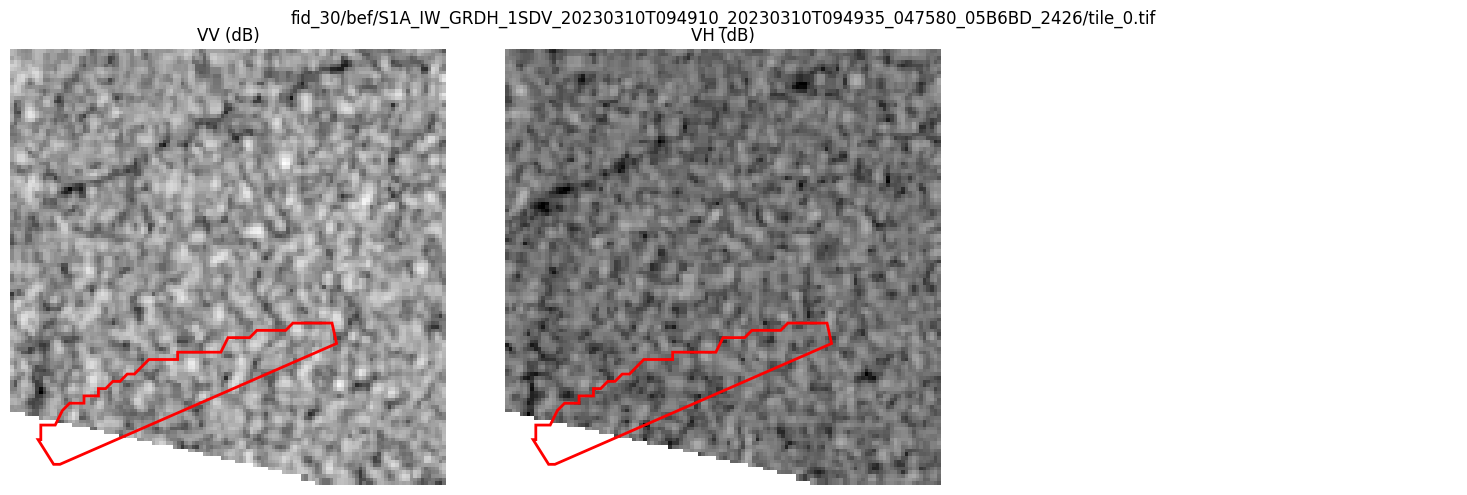

In [8]:
# S1 GRD preview (VV, VH, false color) with the FID polygon overlaid
s1 = "/share/home/e2406749/thesis_tiles_120px/s1_grd/fid_30/bef/S1A_IW_GRDH_1SDV_20230310T094910_20230310T094935_047580_05B6BD_2426/tile_0.tif"

plot_s1(s1, vmin=-25, vmax=0)

## S1 statistics

In [13]:
# S1 backscatter statistics over all GRD tiles (nodata excluded)
tifs = glob.glob("/share/home/e2406749/thesis_tiles_120px/s1_grd/fid_*/*/*/tile_*.tif")
arrs = []
for t in tifs:
    with rasterio.open(t) as s:
        a = s.read().astype("float32")
    arrs.append(a[:, ~(a == 0).all(axis=0)])   # drop nodata (both bands 0)

vv, vh = np.concatenate([a[0] for a in arrs]), np.concatenate([a[1] for a in arrs])
for name, x in [("VV", vv), ("VH", vh)]:
    print(f"{name}: min={x.min():.2f} mean={x.mean():.2f} std={x.std():.2f} max={x.max():.2f}")

VV: min=-48.45 mean=-8.32 std=2.52 max=7.77
VH: min=-57.30 mean=-14.56 std=2.68 max=2.78


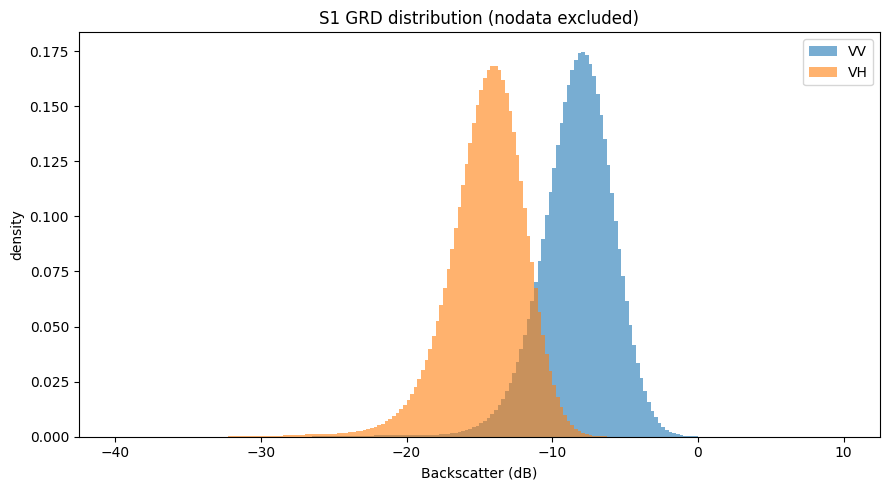

In [15]:
plt.figure(figsize=(9, 5))
plt.hist(vv, bins=200, range=(-40, 10), alpha=0.6, label="VV", density=True)
plt.hist(vh, bins=200, range=(-40, 10), alpha=0.6, label="VH", density=True)
plt.xlabel("Backscatter (dB)"); plt.ylabel("density")
plt.title("S1 GRD distribution (nodata excluded)")
plt.legend(); plt.tight_layout(); plt.show()

## 6. Disk usage summary

In [ ]:
print(f"{'Model':<10} {'Product':<10} {'Size (GB)':>10} {'Files':>8}")
print("-" * 44)
total_gb = 0
total_files = 0
for model, cfg in TILE_SETS.items():
    for product in cfg["products"]:
        product_dir = os.path.join(cfg["dir"], product)
        if os.path.exists(product_dir):
            gb = dir_size_gb(product_dir)
            n_files = sum(len(downloaded[model][product][w]) for w in WINDOWS)
            total_gb += gb
            total_files += n_files
            print(f"{model:<10} {product:<10} {gb:>10.3f} {n_files:>8}")
        else:
            print(f"{model:<10} {product:<10} {'N/A':>10} {'N/A':>8}")
print("-" * 44)
print(f"{'TOTAL':<10} {'':<10} {total_gb:>10.3f} {total_files:>8}")

## 7. Grid alignment artifact (per FID)

Same polygon, three tile sizes. The grid is anchored to the EPSG:3857 origin (multiples of `tile_size_m`), not the polygon. A polygon located near a 2240 m grid boundary can be split into 4 TerraFM tiles while landing inside a single CROMA or Clay tile.

In [ ]:
poly_row = _gdf[_gdf["fid"] == TARGET_FID]
if poly_row.empty:
    raise ValueError(f"FID {TARGET_FID} not in shapefile")
poly_3857 = poly_row.to_crs("EPSG:3857").geometry.iloc[0]
area_km2 = poly_3857.area / 1e6
print(f"FID {TARGET_FID}: area {area_km2:.3f} km², bbox = {[round(v, 1) for v in poly_3857.bounds]}")

# ── Visualization: 1x3, one model per panel ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (model, cfg) in zip(axes, TILE_SETS.items()):
    tile_size_m = cfg["size"] * 10
    tiles = create_tile_grid(poly_3857, tile_size_m)

    pminx, pminy, pmaxx, pmaxy = poly_3857.bounds
    ext_minx = pminx - tile_size_m
    ext_maxx = pmaxx + tile_size_m
    ext_miny = pminy - tile_size_m
    ext_maxy = pmaxy + tile_size_m

    gx = math.floor(ext_minx / tile_size_m) * tile_size_m
    while gx <= ext_maxx:
        ax.axvline(gx, color="gray", lw=0.5, alpha=0.4)
        gx += tile_size_m
    gy = math.floor(ext_miny / tile_size_m) * tile_size_m
    while gy <= ext_maxy:
        ax.axhline(gy, color="gray", lw=0.5, alpha=0.4)
        gy += tile_size_m

    for t in tiles:
        tx, ty = t.exterior.xy
        ax.fill(tx, ty, alpha=0.25, color="blue", edgecolor="blue", linewidth=2)

    geoms = [poly_3857] if poly_3857.geom_type == "Polygon" else list(poly_3857.geoms)
    for g in geoms:
        px, py = g.exterior.xy
        ax.fill(px, py, alpha=0.7, color="red", edgecolor="darkred", linewidth=2)

    ax.set_xlim(ext_minx, ext_maxx)
    ax.set_ylim(ext_miny, ext_maxy)
    ax.set_aspect("equal")
    ax.set_title(f"{model} — {cfg['size']}² ({tile_size_m} m) — {len(tiles)} tile(s)", fontsize=11)
    ax.set_xlabel("X (m, EPSG:3857)")
    ax.set_ylabel("Y (m, EPSG:3857)")

legend_handles = [
    mpatches.Patch(color="red", alpha=0.7, label="polygon"),
    mpatches.Patch(color="blue", alpha=0.25, label="downloaded tile"),
    mpatches.Patch(color="gray", alpha=0.4, label="grid lines (tile_size_m)"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))
plt.suptitle(f"FID {TARGET_FID} — grid alignment artifact (same polygon, 3 grid sizes)",
             fontsize=13, y=1.06)
plt.tight_layout()
plt.show()


# ── Real on-disk tile counts for the target FID ──
print(f"\nTile counts on disk for FID {TARGET_FID}:")
print(f"{'Model':<10} {'Product':<10} {'evt':>6} {'bef':>6} {'aft':>6} {'TOTAL':>7}")
print("-" * 50)
for model, cfg in TILE_SETS.items():
    for product in cfg["products"]:
        counts = {}
        for window in WINDOWS:
            win_dir = os.path.join(cfg["dir"], product, f"fid_{TARGET_FID}", window)
            if not os.path.exists(win_dir):
                counts[window] = 0
                continue
            n_tiles_per_img = []
            for img in os.listdir(win_dir):
                full = os.path.join(win_dir, img)
                if os.path.isdir(full):
                    n_tiles_per_img.append(len(glob.glob(os.path.join(full, "tile_*.tif"))))
            counts[window] = max(n_tiles_per_img) if n_tiles_per_img else 0
        total = sum(counts.values())
        print(f"{model:<10} {product:<10} {counts['evt']:>6} {counts['bef']:>6} {counts['aft']:>6} {total:>7}")

# Delete noisy image

In [ ]:
# Find and delete a specific noisy acquisition (2023-09-07) across all tile sets
date_token = "20230907"  # 2023-09-07

for model, cfg in TILE_SETS.items():
    for product in cfg["products"]:
        pattern = os.path.join(cfg["dir"], product, "fid_*", "*", f"*{date_token}*")
        for img_path in glob.glob(pattern):
            if os.path.isdir(img_path):
                print("deleting", img_path)
                shutil.rmtree(img_path)

## Duplicates — S2 (MGRS overlap)

`duplicates_check` keeps the first folder per acquisition day and reports the rest.
Run with `delete_=False` to review, then `delete_=True` to remove.

In [ ]:
duplicates_check(delete_=False)

In [ ]:
dup_groups = []   # each: {fid, window, day, tiles: {code: image_id}}
for model, cfg in TILE_SETS.items():
    for window_dir in sorted(glob.glob(os.path.join(cfg["dir"], PRODUCT, "fid_*", "*"))):
        by_day = defaultdict(dict)
        for leaf in sorted(os.listdir(window_dir)):
            if os.path.isdir(os.path.join(window_dir, leaf)):
                by_day[leaf[:8]][leaf.split("_")[-1]] = leaf   # {code: image_id}
        for day, tiles in by_day.items():
            if len(tiles) >= 2:
                dup_groups.append({
                    "dir":    cfg["dir"],
                    "fid":    os.path.basename(os.path.dirname(window_dir)).replace("fid_", ""),
                    "window": os.path.basename(window_dir),
                    "day":    day,
                    "tiles":  tiles,
                })

In [ ]:
print(f"Duplicate groups: {len(dup_groups)}")

In [ ]:
duplicates_check(delete_=True)

In [ ]:
duplicates_check(delete_=False)

## Duplicates — S1 (frame overlap)

S1 has no MGRS grid, so the S2 duplicate logic doesn't apply. Here all S1 is **descending**, so two folders on the same acquisition day are the same pass split across two overlapping GRD frames (footprint near a frame edge). Group by acquisition date (regex, since S1 folders start with `S1A_...` not the date), keep the frame with least nodata, report the rest. `delete_=False` by default — review before deleting.

In [14]:
duplicates_check_s1(delete_=True)


Frames to delete: 0
FIDs with S1 overlap duplicates: []
Total unique FIDs with S1 duplicates: 0


# Longest time series - based on joint embeddings

Longest time series per type of deforestation depending on the joint embeddings

In [19]:
# ── Top-2 longest JOINT time series per disturbance type (from joint embeddings) ──
# embeddings/joint/fid_<fid>/<window>/<s2id>__<s1id>/tile_N.npy
JOINT_ROOT = os.path.join(SCRIPT_DIR, "embeddings", "joint")

# fid -> {window: set(pair_id)}
series = defaultdict(lambda: defaultdict(set))
for npy in glob.glob(os.path.join(JOINT_ROOT, "fid_*", "*", "*", "*.npy")):
    fid, window, pair = Path(npy).parts[-4:-1]
    series[fid.replace("fid_", "")][window].add(pair)

# keep FIDs with >= 1 joint pair in every window, take top-2 longest series per type
by_type = defaultdict(list)
for fid, wins in series.items():
    if all(wins.get(w) for w in WINDOWS):
        by_type[fid_to_type.get(fid, "?")].append((fid, sum(len(w) for w in wins.values())))

print(f"{'Disturbance type':<25} {'rank':>4} {'fid':>6} {'#joint':>7}")
print("-" * 47)
for ctype, fids in sorted(by_type.items()):
    top2 = sorted(fids, key=lambda x: (-x[1], int(x[0])))[:2]   # most pairs, tie -> lower fid
    for rank, (fid, count) in enumerate(top2, 1):
        print(f"{ctype:<25} {rank:>4} {fid:>6} {count:>7}")


Disturbance type          rank    fid  #joint
-----------------------------------------------
Clear-cut bare soil          1    214      19
Clear-cut bare soil          2    333      19
Clear-cut vegetation         1    318      13
Clear-cut vegetation         2    191       9
Degradation                  1    389      19
Degradation                  2     23      15
Disorderly Selective logging    1      3      15
Disorderly Selective logging    2      2      12
Fire scar                    1     25      19
Fire scar                    2     10      18
Geometric Selective logging    1     78      13
Geometric Selective logging    2    382      11
